## Cargar dataset

In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\Diego\Downloads\SeoulBikeData.csv", encoding='cp1252')

# Display the first few rows to verify the data was loaded correctly
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [8]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


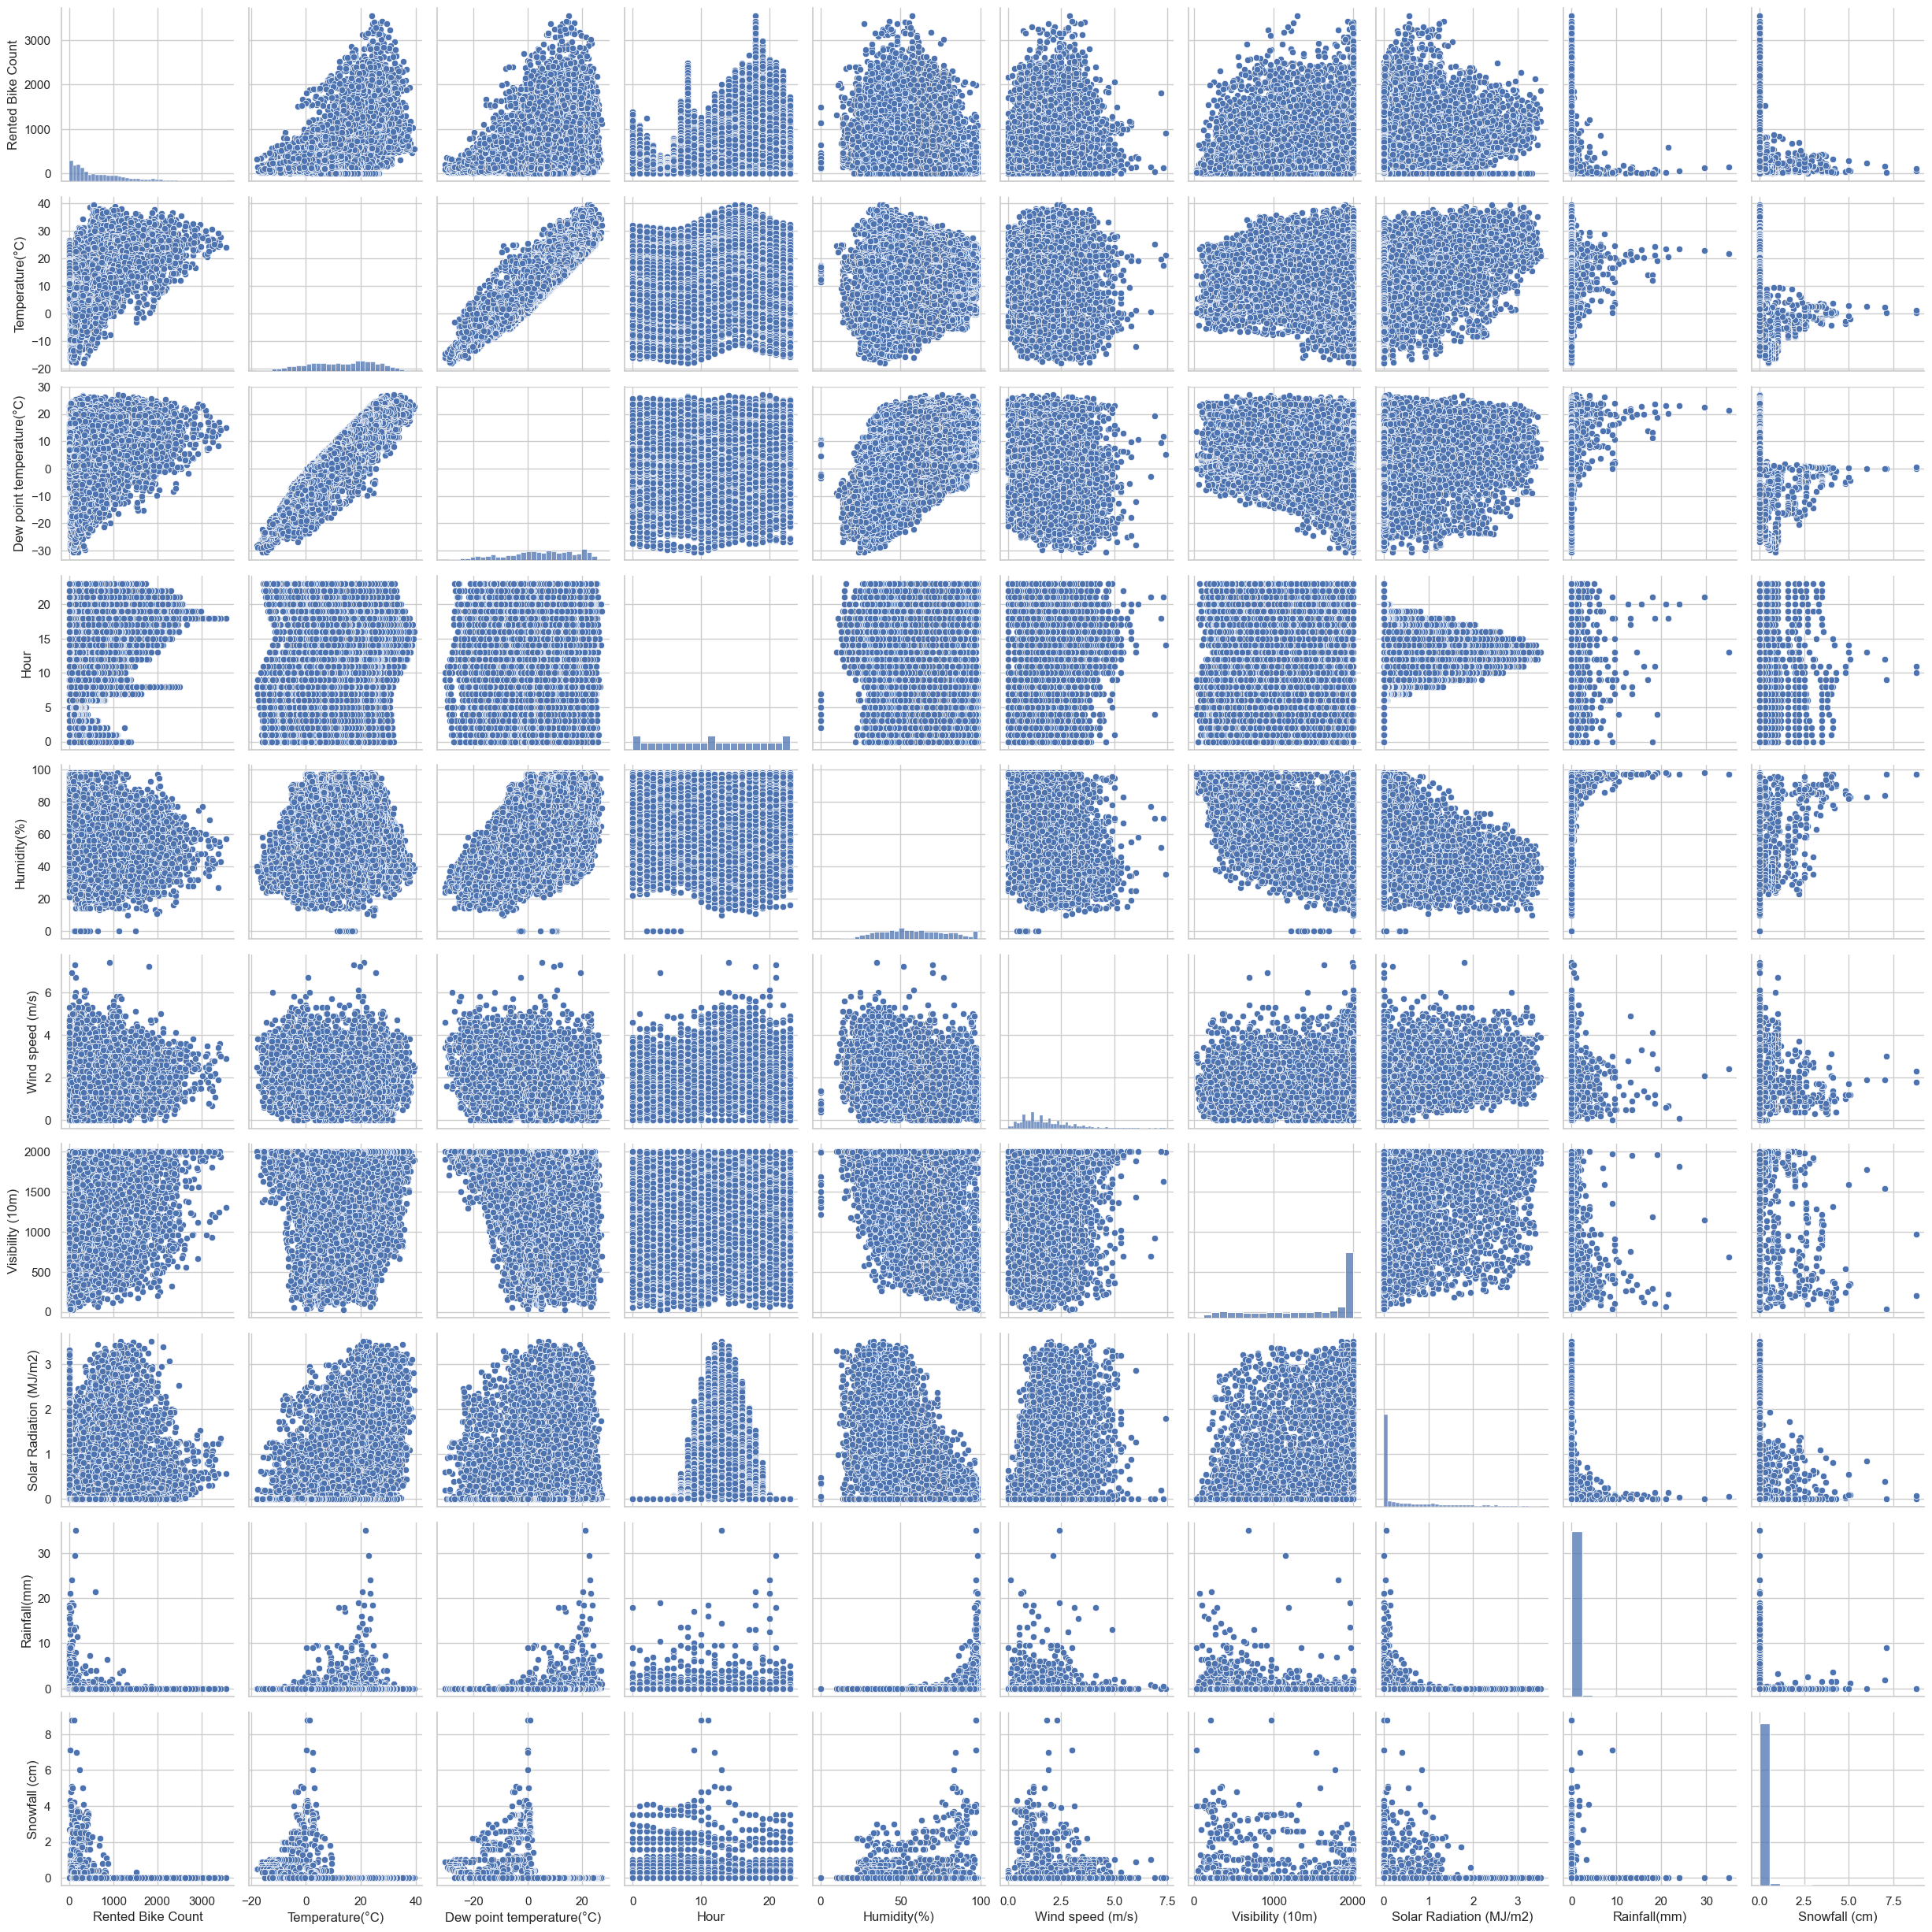

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid", context="notebook")
cols = ['Rented Bike Count', 'Temperature(°C)', 'Dew point temperature(°C)', 'Hour', 'Humidity(%)', 
		'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
sns.pairplot(df[cols], height=2.5)
plt.show()

<Axes: >

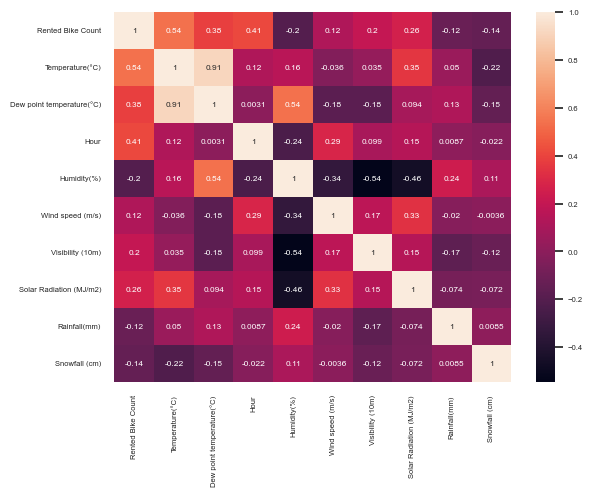

In [11]:
import numpy as np
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=0.5)
sns.heatmap(cm, cbar=True, annot=True, 
            yticklabels=cols, xticklabels=cols)

In [14]:
new_df = df[['Temperature(°C)', 'Dew point temperature(°C)', 'Hour', 'Seasons', 'Holiday', 'Rented Bike Count']]
new_df.head()

,Temperature(°C),Dew point temperature(°C),Hour,Seasons,Holiday,Rented Bike Count
0,-5.2,-17.6,0,Winter,No Holiday,254
1,-5.5,-17.6,1,Winter,No Holiday,204
2,-6.0,-17.7,2,Winter,No Holiday,173
3,-6.2,-17.6,3,Winter,No Holiday,107
4,-6.0,-18.6,4,Winter,No Holiday,78


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Configurar el estilo para las visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Imprimir nombres de columnas para verificar
print("\nNombres de columnas:")
print(df.columns.tolist())


Nombres de columnas:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [17]:
# 2. Seleccionar las columnas de interés basadas en los nombres reales
# Variables numéricas
numeric_features = ['Temperature', 'Dew_point_temperature', 'Hour']

# Variables categóricas
# Seasons está codificada como dummies: Seasons_Spring, Seasons_Summer, Seasons_Winter
# La categoría base (Autumn) se infiere cuando todas las anteriores son 0
categorical_features = ['Holiday']
seasons_dummies = ['Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter']

In [19]:
# First, create dummy variables for Seasons
df_with_dummies = pd.get_dummies(df, columns=['Seasons'], prefix='Seasons')

# Adjust column names to match the actual names in the DataFrame
numeric_features = ['Temperature(°C)', 'Dew point temperature(°C)', 'Hour']
selected_columns = numeric_features + categorical_features + ['Seasons_Winter', 'Seasons_Spring', 'Seasons_Summer'] + ['Rented Bike Count']

# Create the final dataset
selected_df = df_with_dummies[selected_columns]

print(f"\nDataset reducido a {selected_df.shape[1]} columnas")
print("\nColumnas seleccionadas:")
print(selected_df.columns.tolist())

# Usar el nuevo dataframe para el análisis
df = selected_df


Dataset reducido a 8 columnas

Columnas seleccionadas:
['Temperature(°C)', 'Dew point temperature(°C)', 'Hour', 'Holiday', 'Seasons_Winter', 'Seasons_Spring', 'Seasons_Summer', 'Rented Bike Count']


### Analisis Exploratorio


--- Resumen estadístico ---
       Temperature(°C)  Dew point temperature(°C)         Hour  \
count      8760.000000                8760.000000  8760.000000   
mean         12.882922                   4.073813    11.500000   
std          11.944825                  13.060369     6.922582   
min         -17.800000                 -30.600000     0.000000   
25%           3.500000                  -4.700000     5.750000   
50%          13.700000                   5.100000    11.500000   
75%          22.500000                  14.800000    17.250000   
max          39.400000                  27.200000    23.000000   

       Rented Bike Count  
count        8760.000000  
mean          704.602055  
std           644.997468  
min             0.000000  
25%           191.000000  
50%           504.500000  
75%          1065.250000  
max          3556.000000  

--- Valores nulos por columna ---
Temperature(°C)              0
Dew point temperature(°C)    0
Hour                         0
Holid

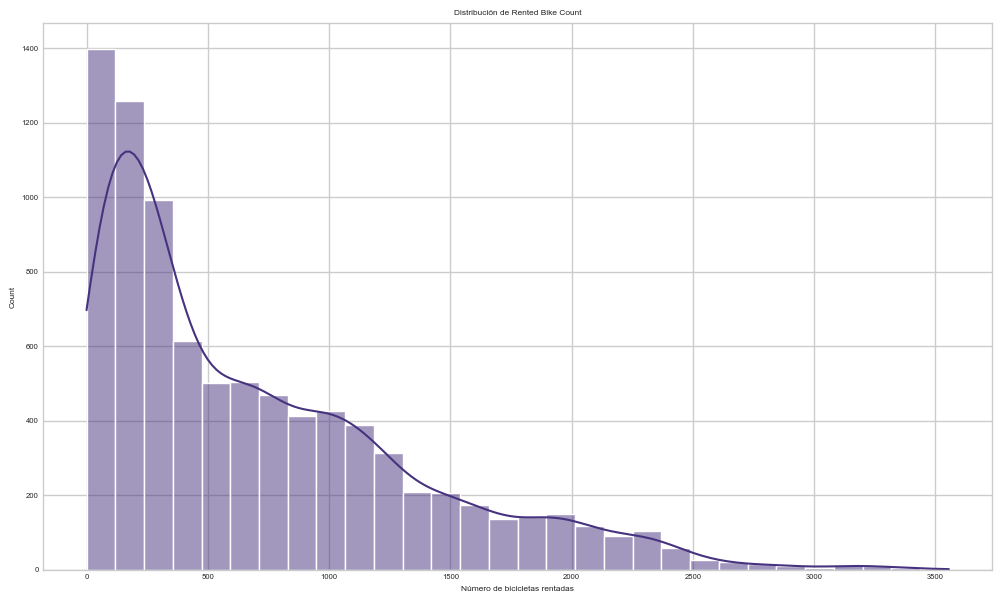


--- Primeras 5 filas del dataset ---
   Temperature(°C)  Dew point temperature(°C)  Hour     Holiday  \
0             -5.2                      -17.6     0  No Holiday   
1             -5.5                      -17.6     1  No Holiday   
2             -6.0                      -17.7     2  No Holiday   
3             -6.2                      -17.6     3  No Holiday   
4             -6.0                      -18.6     4  No Holiday   

   Seasons_Winter  Seasons_Spring  Seasons_Summer  Rented Bike Count  
0            True           False           False                254  
1            True           False           False                204  
2            True           False           False                173  
3            True           False           False                107  
4            True           False           False                 78  

--- Distribución de variables categóricas ---
Holiday:
Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64


In [21]:
# 2. Análisis Exploratorio de Datos

# 2.1 Resumen estadístico
print("\n--- Resumen estadístico ---")
print(df.describe())

# 2.2 Verificar valores nulos
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())

# 2.3 Analizar la distribución de la variable objetivo
plt.figure(figsize=(10, 6))
sns.histplot(df['Rented Bike Count'], kde=True, bins=30)
plt.title('Distribución de Rented Bike Count')
plt.xlabel('Número de bicicletas rentadas')
plt.tight_layout()
plt.show()

# 2.4 Mostrar primeras filas del dataset
print("\n--- Primeras 5 filas del dataset ---")
print(df.head())

# 2.5 Análisis de variables categóricas
print("\n--- Distribución de variables categóricas ---")
print("Holiday:")
print(df['Holiday'].value_counts())

In [22]:
# Crear variable de temporada a partir de las dummies para visualización
df['Season'] = 'Autumn'  # Valor por defecto (cuando todas las dummies son 0)
df.loc[df['Seasons_Spring'] == 1, 'Season'] = 'Spring'
df.loc[df['Seasons_Summer'] == 1, 'Season'] = 'Summer'
df.loc[df['Seasons_Winter'] == 1, 'Season'] = 'Winter'

print("\nSeason (derivada de dummies):")
print(df['Season'].value_counts())

plt.figure(figsize=(14, 6))


Season (derivada de dummies):
Season
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64


<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

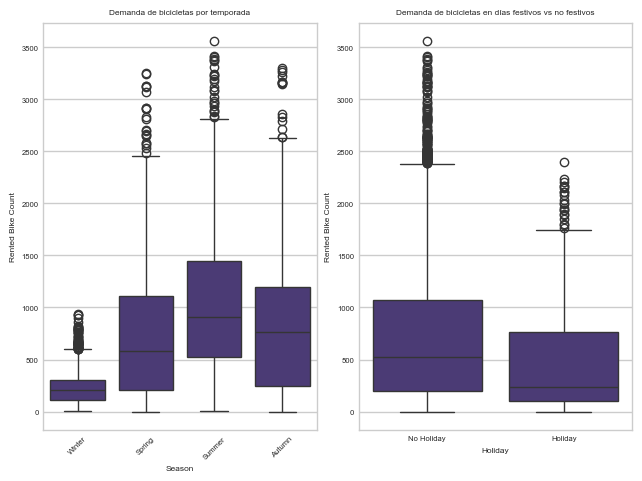

In [24]:
# Análisis por temporada
plt.subplot(1, 2, 1)
sns.boxplot(x='Season', y='Rented Bike Count', data=df)
plt.title('Demanda de bicicletas por temporada')
plt.xticks(rotation=45)

# Análisis por día festivo
plt.subplot(1, 2, 2)
sns.boxplot(x='Holiday', y='Rented Bike Count', data=df)
plt.title('Demanda de bicicletas en días festivos vs no festivos')

plt.tight_layout()
plt.show()

In [26]:
# 3. Preparación de datos para modelado

# 3.1 Dividir en conjuntos de entrenamiento y prueba
# Eliminar la columna 'Season' que creamos solo para visualización
df_model = df.drop('Season', axis=1)

X = df_model.drop('Rented Bike Count', axis=1)
y = df_model['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
print(f"\nConjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

# 3.2 Crear un pipeline para preprocesamiento y modelado
# Solo necesitamos escalar las variables numéricas, ya que las categóricas ya están codificadas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'  # Mantener las otras columnas (dummies de temporada y Holiday)
)

# Función para evaluar modelo en train y test
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Predecir en conjunto de entrenamiento
    y_pred_train = model.predict(X_train)
    
    # Métricas en entrenamiento
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    
    # Predecir en conjunto de prueba
    y_pred_test = model.predict(X_test)
    
    # Métricas en prueba
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    
    # Imprimir resultados
    print(f"\n--- Evaluación del modelo {model_name} ---")
    print(f"Conjunto de entrenamiento:")
    print(f"  RMSE: {rmse_train:.2f}")
    print(f"  MAE: {mae_train:.2f}")
    print(f"  R²: {r2_train:.2f}")
    
    print(f"Conjunto de prueba:")
    print(f"  RMSE: {rmse_test:.2f}")
    print(f"  MAE: {mae_test:.2f}")
    print(f"  R²: {r2_test:.2f}")
    
    # Calcular la diferencia para verificar sobreajuste
    rmse_diff = rmse_train - rmse_test
    r2_diff = r2_train - r2_test
    
    if abs(r2_diff) > 0.1:
        if r2_diff > 0:
            print(f"ALERTA: Posible sobreajuste (R² train > R² test por {r2_diff:.2f})")
        else:
            print(f"NOTA: El modelo generaliza bien en prueba (R² test > R² train por {-r2_diff:.2f})")
    else:
        print("El modelo muestra un buen balance entre ajuste y generalización")
    
    return {
        'model': model,
        'predictions_train': y_pred_train,
        'predictions_test': y_pred_test,
        'metrics_train': {'RMSE': rmse_train, 'MAE': mae_train, 'R²': r2_train},
        'metrics_test': {'RMSE': rmse_test, 'MAE': mae_test, 'R²': r2_test}
    }



Conjunto de entrenamiento: 6132 muestras
Conjunto de prueba: 2628 muestras


In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# 4. Evaluación de modelos
# Configurar validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=123)

# Actualizar el preprocesador para manejar variables categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'  # Mantener las otras columnas (dummies de temporada)
)

# 4.1 Modelo de referencia: Regresión Lineal
print("\n--- Entrenando modelo de referencia (Regresión Lineal) ---")
baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar el modelo
baseline_pipe.fit(X_train, y_train)

# Validación cruzada
baseline_scores = cross_val_score(baseline_pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
baseline_rmse_cv = -baseline_scores.mean()
print(f"RMSE promedio (validación cruzada): {baseline_rmse_cv:.2f}")

# Evaluar en train y test
baseline_results = evaluate_model(baseline_pipe, X_train, y_train, X_test, y_test, "Regresión Lineal")

# 4.2 Modelo Random Forest
print("\n--- Entrenando modelo Random Forest ---")
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=123))
])

# Validación cruzada para Random Forest
rf_scores = cross_val_score(rf_pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rf_rmse_cv = -rf_scores.mean()
print(f"RMSE promedio (validación cruzada): {rf_rmse_cv:.2f}")

# Entrenar en todo el conjunto de entrenamiento
rf_pipe.fit(X_train, y_train)

# Evaluar en train y test
rf_results = evaluate_model(rf_pipe, X_train, y_train, X_test, y_test, "Random Forest")

# 4.3 Modelo KNN
print("\n--- Entrenando modelo KNN ---")

# Para KNN, primero encontramos el mejor valor de k mediante validación cruzada
param_grid = {'regressor__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19]}

knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# Búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(
    knn_pipe, 
    param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Obtener el mejor valor de k
best_k = grid_search.best_params_['regressor__n_neighbors']
print(f"Mejor valor de k: {best_k}")

# Usar el mejor modelo KNN
best_knn_pipe = grid_search.best_estimator_
knn_rmse_cv = -grid_search.best_score_
print(f"RMSE promedio (validación cruzada): {knn_rmse_cv:.2f}")

# Evaluar en train y test
knn_results = evaluate_model(best_knn_pipe, X_train, y_train, X_test, y_test, f"KNN (k={best_k})")

# 4.4 Modelo SVR (Support Vector Regression)
print("\n--- Entrenando modelo SVR ---")

# Para SVR, encontramos los mejores hiperparámetros mediante validación cruzada
svr_param_grid = {
    'regressor__C': [0.1, 1, 10, 100],
    'regressor__gamma': ['scale', 'auto', 0.1, 0.01],
    'regressor__kernel': ['rbf']
}

svr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])


--- Entrenando modelo de referencia (Regresión Lineal) ---
RMSE promedio (validación cruzada): 474.40

--- Evaluación del modelo Regresión Lineal ---
Conjunto de entrenamiento:
  RMSE: 474.03
  MAE: 348.49
  R²: 0.47
Conjunto de prueba:
  RMSE: 470.76
  MAE: 353.19
  R²: 0.45
El modelo muestra un buen balance entre ajuste y generalización

--- Entrenando modelo Random Forest ---
RMSE promedio (validación cruzada): 330.76

--- Evaluación del modelo Random Forest ---
Conjunto de entrenamiento:
  RMSE: 123.28
  MAE: 71.69
  R²: 0.96
Conjunto de prueba:
  RMSE: 337.88
  MAE: 200.41
  R²: 0.72
ALERTA: Posible sobreajuste (R² train > R² test por 0.25)

--- Entrenando modelo KNN ---
Mejor valor de k: 7
RMSE promedio (validación cruzada): 333.93

--- Evaluación del modelo KNN (k=7) ---
Conjunto de entrenamiento:
  RMSE: 283.85
  MAE: 172.52
  R²: 0.81
Conjunto de prueba:
  RMSE: 330.82
  MAE: 203.72
  R²: 0.73
El modelo muestra un buen balance entre ajuste y generalización

--- Entrenando mod

Buscando mejores hiperparámetros para SVR (puede tardar)...
Mejores hiperparámetros: C=100, gamma=scale, kernel=rbf
RMSE promedio (validación cruzada): 410.42

--- Evaluación del modelo SVR (C=100, gamma=scale) ---
Conjunto de entrenamiento:
  RMSE: 407.23
  MAE: 248.14
  R²: 0.61
Conjunto de prueba:
  RMSE: 410.42
  MAE: 250.99
  R²: 0.58
El modelo muestra un buen balance entre ajuste y generalización

--- Comparación de modelos ---
               Model     CV RMSE  Train RMSE   Test RMSE  Train R²   Test R²
0  Linear Regression  474.398120  474.027072  470.759862  0.467170  0.449410
1      Random Forest  330.757460  123.283392  337.881826  0.963959  0.716365
2          KNN (k=7)  333.933468  283.854184  330.819380  0.808939  0.728099
3        SVR (C=100)  410.422873  407.229532  410.424736  0.606757  0.581499

--- Análisis de sobreajuste ---
               Model  RMSE diff (Train-Test)  R² diff (Train-Test)
0  Linear Regression                3.267210              0.017760
1      Ran

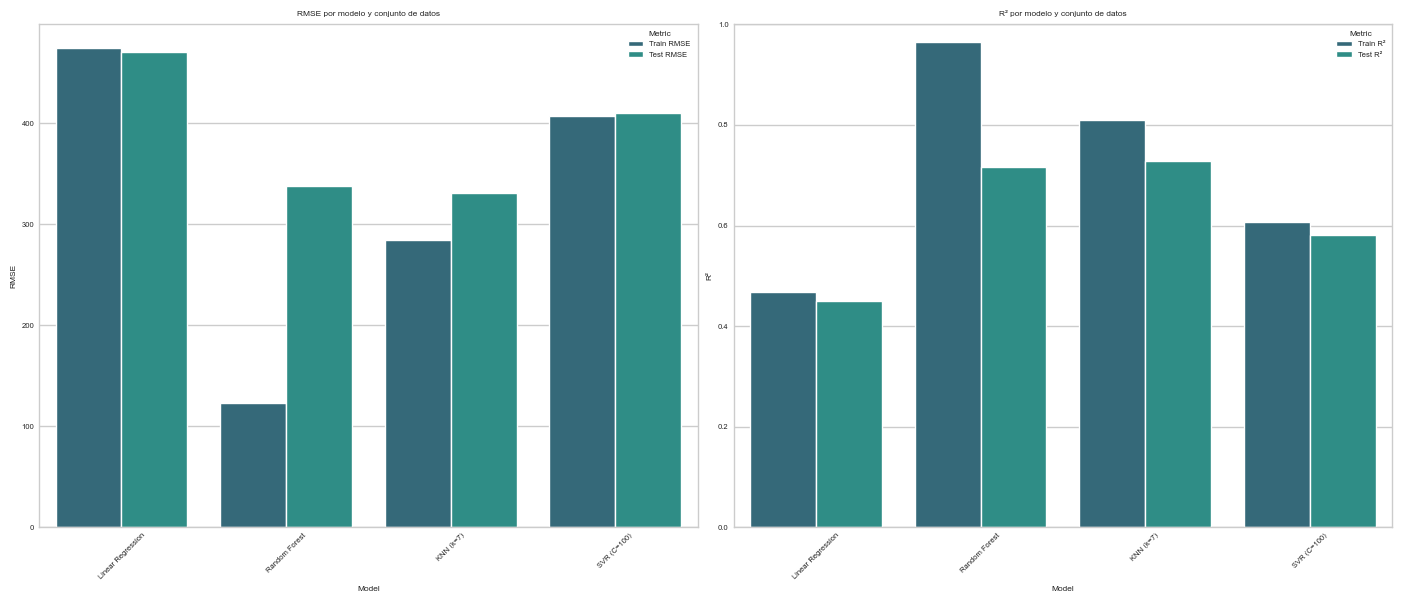

In [34]:
# Búsqueda de hiperparámetros con validación cruzada
# Para ahorrar tiempo, podemos usar una muestra más pequeña o reducir los parámetros a probar
print("Buscando mejores hiperparámetros para SVR (puede tardar)...")
svr_grid_search = GridSearchCV(
    svr_pipe, 
    svr_param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

svr_grid_search.fit(X_train, y_train)

# Obtener los mejores hiperparámetros
best_C = svr_grid_search.best_params_['regressor__C']
best_gamma = svr_grid_search.best_params_['regressor__gamma']
best_kernel = svr_grid_search.best_params_['regressor__kernel']
print(f"Mejores hiperparámetros: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")

# Usar el mejor modelo SVR
best_svr_pipe = svr_grid_search.best_estimator_
svr_rmse_cv = -svr_grid_search.best_score_
print(f"RMSE promedio (validación cruzada): {svr_rmse_cv:.2f}")

# Evaluar en train y test
svr_results = evaluate_model(best_svr_pipe, X_train, y_train, X_test, y_test, f"SVR (C={best_C}, gamma={best_gamma})")

# 5. Comparación de modelos
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', f'KNN (k={best_k})', f'SVR (C={best_C})'],
    'CV RMSE': [baseline_rmse_cv, rf_rmse_cv, knn_rmse_cv, svr_rmse_cv],
    'Train RMSE': [baseline_results['metrics_train']['RMSE'], 
                  rf_results['metrics_train']['RMSE'], 
                  knn_results['metrics_train']['RMSE'],
                  svr_results['metrics_train']['RMSE']],
    'Test RMSE': [baseline_results['metrics_test']['RMSE'], 
                 rf_results['metrics_test']['RMSE'], 
                 knn_results['metrics_test']['RMSE'],
                 svr_results['metrics_test']['RMSE']],
    'Train R²': [baseline_results['metrics_train']['R²'], 
                rf_results['metrics_train']['R²'], 
                knn_results['metrics_train']['R²'],
                svr_results['metrics_train']['R²']],
    'Test R²': [baseline_results['metrics_test']['R²'], 
               rf_results['metrics_test']['R²'], 
               knn_results['metrics_test']['R²'],
               svr_results['metrics_test']['R²']]
})

print("\n--- Comparación de modelos ---")
print(models_comparison)

# Calcular diferencia entre Train y Test para detectar sobreajuste
models_comparison['RMSE diff (Train-Test)'] = models_comparison['Train RMSE'] - models_comparison['Test RMSE']
models_comparison['R² diff (Train-Test)'] = models_comparison['Train R²'] - models_comparison['Test R²']

print("\n--- Análisis de sobreajuste ---")
print(models_comparison[['Model', 'RMSE diff (Train-Test)', 'R² diff (Train-Test)']])

# Visualizar comparación solo de Train RMSE y Test RMSE (sin CV RMSE)
plt.figure(figsize=(14, 6))
models_comparison_plot = models_comparison.melt(id_vars='Model', 
                                              value_vars=['Train RMSE', 'Test RMSE'],
                                              var_name='Metric', value_name='RMSE')

# Definir una paleta personalizada similar a la original
custom_palette = ['#2a6f84', '#1f9d93']  # Azul, Verde-azulado

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='RMSE', hue='Metric', data=models_comparison_plot, palette=custom_palette)
plt.title('RMSE por modelo y conjunto de datos')
plt.xticks(rotation=45)
plt.ylim(bottom=0)  # Iniciar desde 0 para mejor comparación

# Visualizar comparación de R²
plt.subplot(1, 2, 2)
models_comparison_r2 = models_comparison.melt(id_vars='Model', 
                                            value_vars=['Train R²', 'Test R²'],
                                            var_name='Metric', value_name='R²')
sns.barplot(x='Model', y='R²', hue='Metric', data=models_comparison_r2, palette=custom_palette)
plt.title('R² por modelo y conjunto de datos')
plt.xticks(rotation=45)
plt.ylim(bottom=0, top=1)  # R² normalmente está entre 0 y 1

plt.tight_layout()
plt.show()


El mejor modelo es: KNN (k=7)


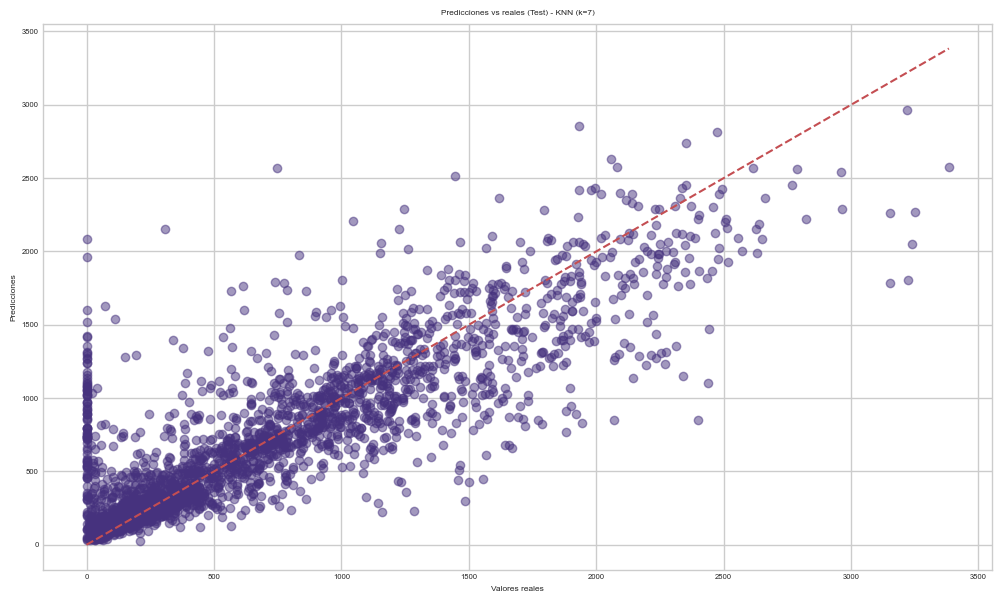


=== RESUMEN FINAL ===
Mejor modelo: KNN (k=7)
Métricas en conjunto de entrenamiento:
  RMSE: 283.85
  MAE: 172.52
  R²: 0.81
Métricas en conjunto de prueba:
  RMSE: 330.82
  MAE: 203.72
  R²: 0.73

--- Resumen de todos los modelos (ordenados por R² en prueba) ---
               Model  Train RMSE   Test RMSE  Train R²   Test R²
2          KNN (k=7)  283.854184  330.819380  0.808939  0.728099
1      Random Forest  123.283392  337.881826  0.963959  0.716365
3        SVR (C=100)  407.229532  410.424736  0.606757  0.581499
0  Linear Regression  474.027072  470.759862  0.467170  0.449410

Análisis y modelado completados.


In [36]:
# 6. Evaluación del mejor modelo
# Encontrar el mejor modelo basado en R² de prueba
best_model_idx = models_comparison['Test R²'].idxmax()
best_model_name = models_comparison.iloc[best_model_idx]['Model']
print(f"\nEl mejor modelo es: {best_model_name}")

# Seleccionar el mejor modelo y sus predicciones
if 'Linear Regression' in best_model_name:
    best_model_pipe = baseline_pipe
    best_results = baseline_results
elif 'Random Forest' in best_model_name:
    best_model_pipe = rf_pipe
    best_results = rf_results
elif 'KNN' in best_model_name:
    best_model_pipe = best_knn_pipe
    best_results = knn_results
else:  # SVR
    best_model_pipe = best_svr_pipe
    best_results = svr_results

# Obtener las predicciones del mejor modelo
y_pred_train = best_results['predictions_train']
y_pred_test = best_results['predictions_test']

# Visualizar predicciones vs reales en conjunto de prueba
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title(f'Predicciones vs reales (Test) - {best_model_name}')
plt.tight_layout()
plt.show()

# 7. Resumen final
print("\n=== RESUMEN FINAL ===")
print(f"Mejor modelo: {best_model_name}")
print(f"Métricas en conjunto de entrenamiento:")
print(f"  RMSE: {best_results['metrics_train']['RMSE']:.2f}")
print(f"  MAE: {best_results['metrics_train']['MAE']:.2f}")
print(f"  R²: {best_results['metrics_train']['R²']:.2f}")
print(f"Métricas en conjunto de prueba:")
print(f"  RMSE: {best_results['metrics_test']['RMSE']:.2f}")
print(f"  MAE: {best_results['metrics_test']['MAE']:.2f}")
print(f"  R²: {best_results['metrics_test']['R²']:.2f}")

# Resumen de todos los modelos evaluados
print("\n--- Resumen de todos los modelos (ordenados por R² en prueba) ---")
print(models_comparison.sort_values('Test R²', ascending=False)[['Model', 'Train RMSE', 'Test RMSE', 'Train R²', 'Test R²']])

print("\nAnálisis y modelado completados.")

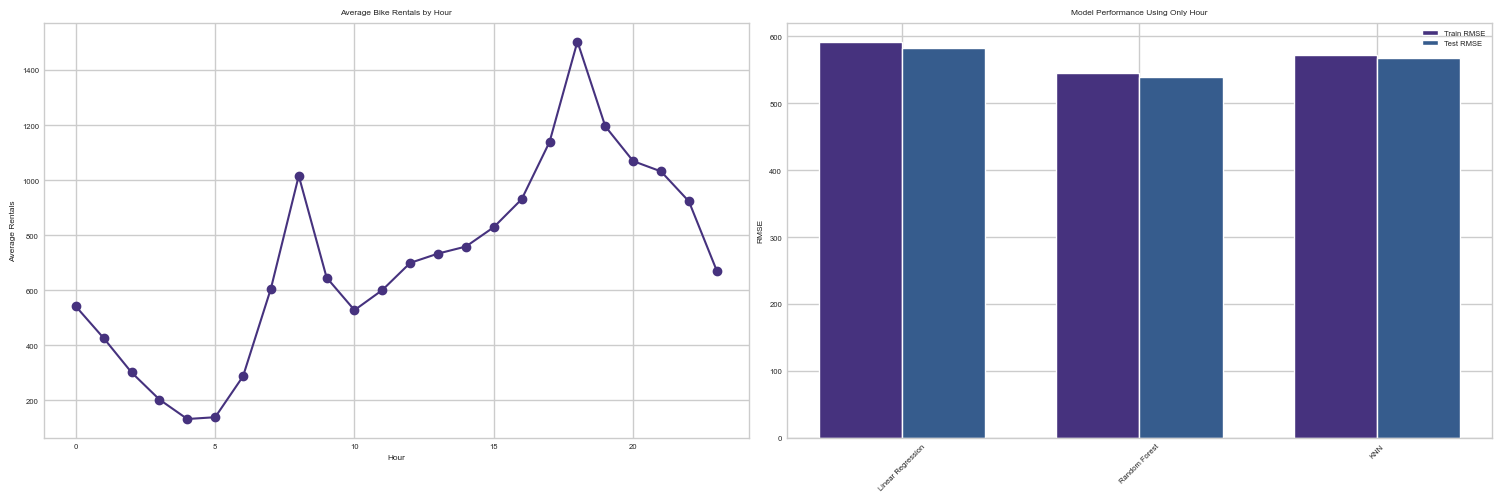


Detailed Results:
--------------------------------------------------

Linear Regression:
Train RMSE: 590.64
Test RMSE: 582.56
Train R²: 0.173
Test R²: 0.157

Random Forest:
Train RMSE: 544.38
Test RMSE: 539.73
Train R²: 0.297
Test R²: 0.276

KNN:
Train RMSE: 572.30
Test RMSE: 567.39
Train R²: 0.223
Test R²: 0.200


In [37]:
# Create a simple model using only Hour as predictor
X_hour = X[['Hour']]
X_hour_train, X_hour_test, y_hour_train, y_hour_test = train_test_split(
    X_hour, y, test_size=0.3, random_state=123
)

# Create and train models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=123),
    'KNN': KNeighborsRegressor(n_neighbors=7)
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_hour_train, y_hour_train)
    
    # Make predictions
    y_pred_train = model.predict(X_hour_train)
    y_pred_test = model.predict(X_hour_test)
    
    # Calculate metrics
    results[name] = {
        'train_rmse': np.sqrt(mean_squared_error(y_hour_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_hour_test, y_pred_test)),
        'train_r2': r2_score(y_hour_train, y_pred_train),
        'test_r2': r2_score(y_hour_test, y_pred_test)
    }

# Create visualization
plt.figure(figsize=(15, 5))

# Plot 1: Average rentals by hour
plt.subplot(1, 2, 1)
hourly_avg = df.groupby('Hour')['Rented Bike Count'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, 'o-')
plt.title('Average Bike Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.grid(True)

# Plot 2: Model Comparison
plt.subplot(1, 2, 2)
model_names = list(results.keys())
train_rmse = [results[name]['train_rmse'] for name in model_names]
test_rmse = [results[name]['test_rmse'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, train_rmse, width, label='Train RMSE')
plt.bar(x + width/2, test_rmse, width, label='Test RMSE')
plt.xticks(x, model_names, rotation=45)
plt.title('Model Performance Using Only Hour')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.show()

# Print detailed results
print("\nDetailed Results:")
print("-" * 50)
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"Train RMSE: {metrics['train_rmse']:.2f}")
    print(f"Test RMSE: {metrics['test_rmse']:.2f}")
    print(f"Train R²: {metrics['train_r2']:.3f}")
    print(f"Test R²: {metrics['test_r2']:.3f}")

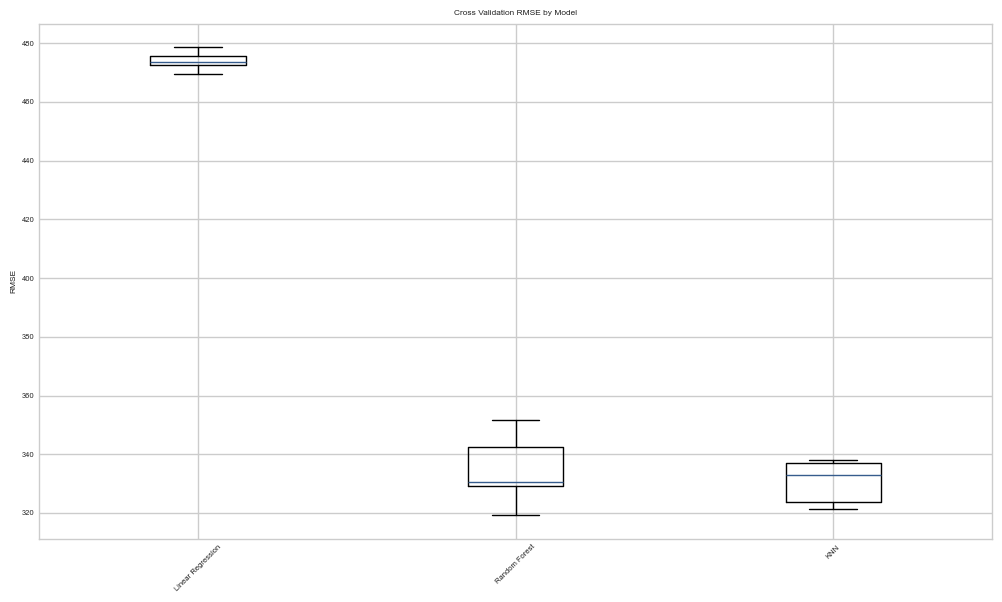


Cross Validation Results (RMSE):
--------------------------------------------------

Linear Regression:
Mean RMSE: 473.99 (+/- 6.21)
Min RMSE: 469.39
Max RMSE: 478.68

Random Forest:
Mean RMSE: 334.54 (+/- 22.52)
Min RMSE: 319.15
Max RMSE: 351.59

KNN:
Mean RMSE: 330.62 (+/- 13.77)
Min RMSE: 321.24
Max RMSE: 338.09


In [40]:
# Define features
numeric_features = ['Temperature(°C)', 'Hour', 'Dew point temperature(°C)']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), ['Season'])
    ])

# Create base models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=123),
    'KNN': KNeighborsRegressor(n_neighbors=7)
}

# Configure cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=123)

# Dictionary to store results
cv_results = {}

# Perform cross validation for each model
for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Perform cross validation
    scores = cross_val_score(
        pipeline,
        df[numeric_features + ['Season']],
        df['Rented Bike Count'],
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )
    
    # Store results
    cv_results[name] = -scores

# Create visualization
plt.figure(figsize=(10, 6))
plt.boxplot([cv_results[name] for name in models.keys()], labels=models.keys())
plt.title('Cross Validation RMSE by Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print detailed results
print("\nCross Validation Results (RMSE):")
print("-" * 50)
for name in models.keys():
    scores = cv_results[name]
    print(f"\n{name}:")
    print(f"Mean RMSE: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")
    print(f"Min RMSE: {scores.min():.2f}")
    print(f"Max RMSE: {scores.max():.2f}")

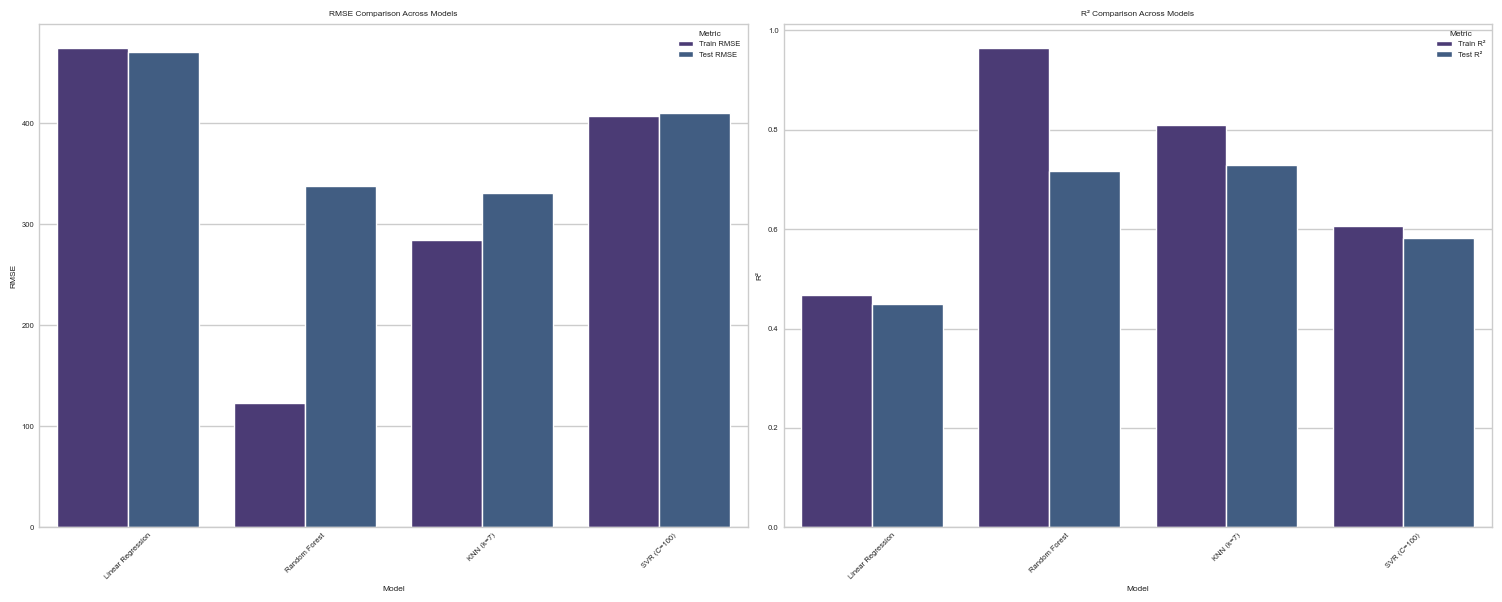


Best Performing Model Summary:
Model: KNN (k=7)
Test RMSE: 330.82
Test R²: 0.7281
Training RMSE: 283.85
Training R²: 0.8089


In [41]:
# Create a bar plot comparing model performance
plt.figure(figsize=(15, 6))

# Plot 1: RMSE Comparison
plt.subplot(1, 2, 1)
metrics_comparison = models_comparison[['Model', 'Train RMSE', 'Test RMSE']].melt(
    id_vars='Model', 
    var_name='Metric', 
    value_name='RMSE'
)
sns.barplot(x='Model', y='RMSE', hue='Metric', data=metrics_comparison)
plt.title('RMSE Comparison Across Models')
plt.xticks(rotation=45)

# Plot 2: R² Comparison
plt.subplot(1, 2, 2)
r2_comparison = models_comparison[['Model', 'Train R²', 'Test R²']].melt(
    id_vars='Model', 
    var_name='Metric', 
    value_name='R²'
)
sns.barplot(x='Model', y='R²', hue='Metric', data=r2_comparison)
plt.title('R² Comparison Across Models')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print summary of best performing model
best_model_idx = models_comparison['Test R²'].idxmax()
best_model = models_comparison.loc[best_model_idx]

print("\nBest Performing Model Summary:")
print(f"Model: {best_model['Model']}")
print(f"Test RMSE: {best_model['Test RMSE']:.2f}")
print(f"Test R²: {best_model['Test R²']:.4f}")
print(f"Training RMSE: {best_model['Train RMSE']:.2f}")
print(f"Training R²: {best_model['Train R²']:.4f}")